In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import yaml

In [6]:
folder = 'anatomy_database/configs/upper_limb'


# Load YAML file
def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

# Add node with explicit type label
def add_node(G, node_id, data, node_type):
    clean_data = {k: v for k, v in data.items() if k != "type"}
    clean_data["node_type"] = node_type
    G.add_node(node_id, **clean_data)

# Base path where your YAMLs are saved
base = Path("/home/tomf/Coding/Freehily/Stronger/stronger/anatomy_database/configs/upper_limb")  # Update this

# Load files
bones = load_yaml(base / "bones.yaml")["bones"]
attachments = load_yaml(base / "attachment_points.yaml")["attachment_points"]
muscle_heads = load_yaml(base / "muscle_heads.yaml")["muscle_heads"]
muscles = load_yaml(base / "muscles.yaml")["muscles"]
nerves = load_yaml(base / "nerves.yaml")["nerves"]
arteries = load_yaml(base / "arteries.yaml")["arteries"]
actions = load_yaml(base / "actions.yaml")["actions"]

# Create graph
G = nx.DiGraph()

# Add bones and attachment points
for bone in bones:
    add_node(G, bone["id"], bone, "bone")
    for ap in bone.get("attachments", []):
        G.add_edge(bone["id"], ap, relation="has_attachment")

for ap in attachments:
    add_node(G, ap["id"], ap, "attachment_point")

# Add muscle heads
for mh in muscle_heads:
    add_node(G, mh["id"], mh, "muscle_head")
    for origin in mh.get("origin", []):
        G.add_edge(mh["id"], origin, relation="origin")
    for insertion in mh.get("insertion", []):
        G.add_edge(mh["id"], insertion, relation="insertion")
    for nerve in mh.get("innervation", []):
        G.add_edge(mh["id"], nerve, relation="innervated_by")
    for artery in mh.get("arteries", []):
        G.add_edge(mh["id"], artery, relation="supplied_by")

# Add muscles
for m in muscles:
    add_node(G, m["id"], m, "muscle")
    for head in m.get("heads", []):
        G.add_edge(m["id"], head, relation="has_head")
    for action in m.get("actions", []):
        G.add_edge(m["id"], action, relation="performs")
    for ant in m.get("antagonists", []):
        G.add_edge(m["id"], ant, relation="antagonist_to")

# Add nerves
for nerve in nerves:
    add_node(G, nerve["id"], nerve, "nerve")

# Add arteries
for artery in arteries:
    add_node(G, artery["id"], artery, "artery")
    if "branches_from" in artery:
        G.add_edge(artery["id"], artery["branches_from"], relation="branches_from")

# Add actions
for action in actions:
    add_node(G, action["id"], action, "action")

print(f"✅ Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")



✅ Graph built with 133 nodes and 164 edges.


In [8]:
# Example 1: What does the biceps_brachii_long attach to?
list(G.successors("biceps_brachii_long"))

['supraglenoid_tuberosity', 'musculocutaneous', 'brachial_artery']

In [13]:
# Example 2: What bones does the triceps_brachii_long insert into?
[
    t for t in G.successors("triceps_brachii_long")
    if G.edges["triceps_brachii_long", t]["relation"] == "insertion"
]

[]

In [10]:
# Example 3: Which muscles are innervated by musculocutaneous nerve?
[
    u for u, v, d in G.in_edges("musculocutaneous", data=True)
    if d["relation"] == "innervated_by"
]

['biceps_brachii_short', 'biceps_brachii_long']

In [11]:
# Example 4: What actions are performed by biceps_brachii?
[
    v for u, v, d in G.edges("biceps_brachii", data=True)
    if d["relation"] == "performs"
]

['elbow_flexion', 'shoulder_flexion', 'forearm_supination']

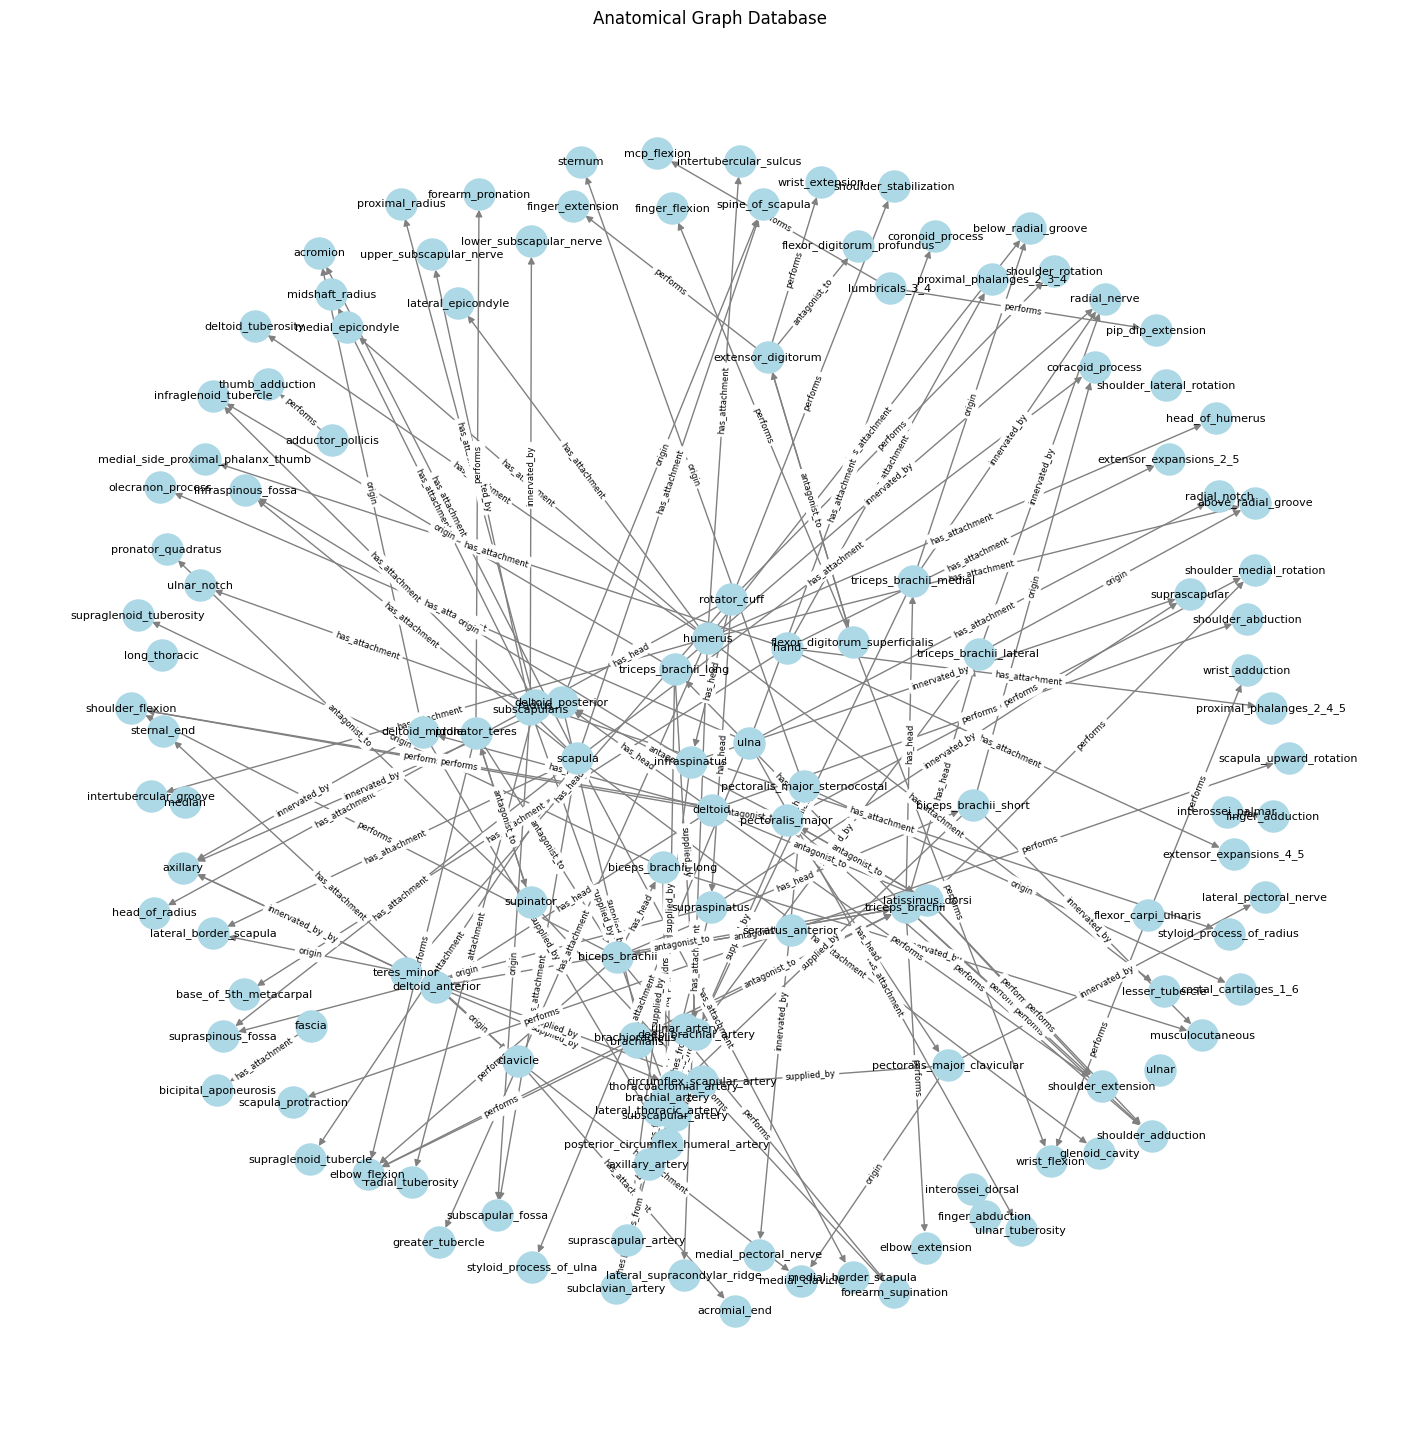

In [ ]:


# Draw the full graph (can be messy if large)
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, seed=42)  # Force-directed layout
nx.draw(G, pos, with_labels=True, node_size=500, font_size=8, node_color="lightblue", edge_color="gray")
edge_labels = nx.get_edge_attributes(G, "relation")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
plt.title("Anatomical Graph Database")
plt.show()
